# Lending Anomaly Discovery using Statistical & Structural Outlier Detection

Fase 4: Anomaly and Outlier Detection

Pada fase ini saya menggali record yang menyimpang jauh dari perilaku mayoritas populasi,
lalu menentukan apakah tiap penyimpangan merupakan kesalahan data, kasus langka yang tetap
sah, atau sinyal risiko yang layak dieskalasi. Saya menjalankan pipeline penuh: memuat data
bersih dari Fase 1, menerapkan tiga metode deteksi yang saling melengkapi (IQR, Z-score, dan
Isolation Forest), membandingkan hasilnya secara sistematis, lalu menyilangkannya dengan
outlier klaster (noise DBSCAN) dari Fase 2 agar temuan berpijak pada bukti berlapis.

Saya memproses dua dataset agar bisa melakukan perbandingan lintas domain:
- Accepted loans: fokus utama, memuat outcome pinjaman (loan_status).
- Rejected loans: dataset komparatif untuk memahami anomali pada pengajuan yang ditolak.

Saya sengaja menghubungkan setiap anomali kembali ke konteks bisnis perbankan, karena tujuan
fase ini bukan sekadar menandai titik ekstrem, melainkan menjelaskan apa arti tiap titik itu
bagi bank dan tindakan apa yang sebaiknya diambil.

# 1. Setup & Konfigurasi Path

Saya mengimpor seluruh library yang saya butuhkan dan menetapkan path data. Default path
mengikuti struktur pipeline Fase 1-2 yang sudah saya susun.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
RANDOM_STATE = 42
print('Library berhasil diimport')

Library berhasil diimport


Saya menetapkan lokasi dua CSV hasil pembersihan Fase 1 dan dua file JSON berisi noise
DBSCAN Fase 2. Saya juga menyiapkan folder output agar seluruh gambar dan laporan anomali
tersimpan rapi untuk dipakai kembali di Fase 5.

In [2]:
# --- Path lokal (mengikuti struktur pipeline Fase 1-2) ---
PATH_ACC   = '../Datasets/Cleaning/Phase 2/clean_accepted_loans.csv'
PATH_REJ   = '../Datasets/Cleaning/Phase 2/clean_rejected_loans.csv'
PATH_DB_ACC = '../Phase 2 Clustering/dbscan_outliers_accepted.json'
PATH_DB_REJ = '../Phase 2 Clustering/dbscan_outliers_rejected.json'

# Folder output
import os
os.makedirs('Results', exist_ok=True)
print('Path dikonfigurasi.')

Path dikonfigurasi.


# 2. Memuat Data Bersih & Noise DBSCAN Fase 2

Saya memuat dua hal sekaligus. Pertama, dataset bersih hasil Fase 1 yang fiturnya sudah
ter-scale, sehingga siap saya proses tanpa transformasi tambahan. Kedua, daftar
noise_global_index dari DBSCAN Fase 2, yaitu record yang di fase sebelumnya sudah
teridentifikasi sebagai titik noise (tidak masuk klaster padat mana pun). Daftar inilah yang
nanti saya jadikan jembatan cross-referencing antara temuan Fase 4 dan temuan Fase 2.

In [3]:
# --- Dataset bersih ---
df_acc = pd.read_csv(PATH_ACC)
df_rej = pd.read_csv(PATH_REJ)
print(f'Accepted : {df_acc.shape[0]:,} baris x {df_acc.shape[1]} kolom')
print(f'Rejected : {df_rej.shape[0]:,} baris x {df_rej.shape[1]} kolom')

# --- Noise DBSCAN dari Fase 2 ---
with open(PATH_DB_ACC) as f: db_acc = json.load(f)
with open(PATH_DB_REJ) as f: db_rej = json.load(f)

noise_idx_acc = set(db_acc['noise_global_index'])
noise_idx_rej = set(db_rej['noise_global_index'])
print(f"\nDBSCAN Accepted : eps={db_acc['eps']:.3f}, {db_acc['n_noise']} noise "
      f"(dari sampel {db_acc['sample_size']:,}, {db_acc['pct_noise']}%)")
print(f"DBSCAN Rejected : eps={db_rej['eps']:.3f}, {db_rej['n_noise']} noise "
      f"(dari sampel {db_rej['sample_size']:,}, {db_rej['pct_noise']}%)")

Accepted : 1,348,099 baris x 15 kolom
Rejected : 27,490,787 baris x 8 kolom

DBSCAN Accepted : eps=2.920, 59 noise (dari sampel 5,000, 1.18%)
DBSCAN Rejected : eps=0.437, 171 noise (dari sampel 5,000, 3.42%)


Perlu saya jelaskan soal indexing. Nilai pada noise_global_index adalah posisi record
pada dataset penuh, bukan index sampel. Karena notebook clustering saya memuat CSV yang sama
lalu (untuk rejected) melakukan reset index, saya memperlakukan angka ini sebagai posisi
baris (iloc) pada dataset yang saya muat di sini. Sel berikutnya saya rancang untuk
memvalidasi bahwa setiap index masih berada dalam rentang, dan melaporkan secara transparan
bila ada yang di luar rentang.

Verifikasi keselarasan index

Saya sudah mengecek angkanya: index global maksimum adalah 1.345.315 pada accepted dan
27.289.535 pada rejected, sedangkan dataset bersih saya berukuran sekitar 1.348.099 baris
(accepted) dan 27.490.787 baris (rejected). Dengan begitu seluruh index masih dalam rentang
dan cross-referencing akan berjalan.

Satu catatan kejujuran metodologis yang saya rasa penting: pipeline accepted membuang baris
berstatus Current/Late, sehingga posisi baris bisa sedikit bergeser relatif terhadap index
global saat DBSCAN dijalankan. Bila DBSCAN saya jalankan pada urutan baris yang identik
dengan CSV ini, pencocokan posisi sudah tepat. Untuk berjaga-jaga, saya menyediakan dua mode
pencocokan: mode posisi baris sebagai default, dan mode berbasis kolom identifier unik bila
saya menyimpan kolom seperti id saat clustering, yang membuat pencocokan sepenuhnya kebal
terhadap pergeseran baris.

In [4]:
# --- Mode pencocokan index DBSCAN ---
MODE = 'iloc'      # 'iloc' = cocokkan sebagai posisi baris (default)
                   # 'id'   = cocokkan lewat kolom identifier unik (paling robust)
ID_COL = None      # mis. 'id' — set bila MODE='id' dan kolom tersedia di CSV

def resolve_noise_positions(df, noise_global, name):
    # Kembalikan set POSISI baris (untuk iloc) yang berkorespondensi ke noise DBSCAN.
    if MODE == 'id' and ID_COL and ID_COL in df.columns:
        # noise_global diasumsikan berisi nilai ID, bukan posisi
        matched = df.index[df[ID_COL].isin(noise_global)].tolist()
        pos = [df.index.get_loc(i) for i in matched]
        print(f'[{name}] MODE=id: {len(pos)}/{len(noise_global)} noise tercocokkan via {ID_COL}')
        return set(pos)
    # MODE iloc
    n = len(df)
    pos = {i for i in noise_global if 0 <= i < n}
    invalid = set(noise_global) - pos
    print(f'[{name}] MODE=iloc: {len(pos)}/{len(noise_global)} index dalam rentang [0,{n:,})')
    if invalid:
        print(f'    -> {len(invalid)} di luar rentang (dilewati): {sorted(invalid)[:5]}...')
    return pos

noise_pos_acc = resolve_noise_positions(df_acc, db_acc['noise_global_index'], 'Accepted')
noise_pos_rej = resolve_noise_positions(df_rej, db_rej['noise_global_index'], 'Rejected')

[Accepted] MODE=iloc: 59/59 index dalam rentang [0,1,348,099)
[Rejected] MODE=iloc: 171/171 index dalam rentang [0,27,490,787)


# 3. Pemilihan Fitur untuk Deteksi Anomali

Saya menjalankan deteksi anomali hanya pada fitur numerik kontinu yang bermakna secara
finansial. Saya mengecualikan kolom target (loan_status_binary) supaya deteksi tidak
terbias oleh label hasil, dan membuang kolom dummy biner agar metode statistik seperti IQR
dan Z-score bekerja pada besaran yang memang kontinu. Untuk rejected, saya memakai tiga fitur
inti yang juga saya pakai pada clustering Fase 2, agar kedua fase konsisten.

In [5]:
# --- Accepted: pilih fitur numerik kontinu (bukan target, bukan dummy biner) ---
exclude_acc = {'loan_status_binary', 'loan_status'}
num_acc = [c for c in df_acc.select_dtypes(include='number').columns
           if c not in exclude_acc and df_acc[c].nunique() > 10]
print('Fitur anomali (Accepted):')
for c in num_acc: print(f'  - {c}')

# --- Rejected: tiga fitur inti yang dipakai clustering Fase 2 ---
num_rej = [c for c in ['Amount Requested', 'Debt-To-Income Ratio', 'Employment Length']
           if c in df_rej.columns]
print('\nFitur anomali (Rejected):')
for c in num_rej: print(f'  - {c}')

Fitur anomali (Accepted):
  - int_rate
  - fico_range_low
  - installment
  - acc_open_past_24mths
  - num_tl_op_past_12m

Fitur anomali (Rejected):
  - Amount Requested
  - Debt-To-Income Ratio
  - Employment Length


# 4. Metode Pertama: IQR (Interquartile Range)

Metode pertama yang saya terapkan adalah aturan Tukey berbasis IQR: sebuah nilai saya anggap
outlier bila berada di luar rentang Q1 dikurangi 1.5 IQR atau Q3 ditambah 1.5 IQR. Saya
menghitungnya per fitur, lalu menjumlahkan berapa banyak fitur yang dilanggar tiap record.
Pendekatan ini sederhana dan mudah dijelaskan ke audiens non-teknis, sehingga cocok sebagai
lapis pertama penyaringan. Saya memakai IQR yang sama seperti yang saya gunakan pada tahap
pembersihan di Fase 1, sehingga logikanya konsisten sepanjang proyek.

In [6]:
def iqr_flags(df, cols):
    # Kembalikan DataFrame boolean (baris x fitur): True bila nilai outlier IQR.
    flags = pd.DataFrame(index=df.index)
    bounds = {}
    for c in cols:
        s = df[c]
        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        flags[c] = (s < lo) | (s > hi)
        bounds[c] = (lo, hi)
    return flags, bounds

iqr_flags_acc, iqr_bounds_acc = iqr_flags(df_acc, num_acc)
df_acc['iqr_n_violations'] = iqr_flags_acc.sum(axis=1)
df_acc['is_outlier_iqr'] = df_acc['iqr_n_violations'] > 0

print('IQR — ringkasan pelanggaran per fitur (Accepted):')
summary_iqr = pd.DataFrame({
    'n_outlier': iqr_flags_acc.sum(),
    'pct_outlier': (iqr_flags_acc.mean()*100).round(2)
}).sort_values('n_outlier', ascending=False)
print(summary_iqr)
print(f"\nTotal record dengan >=1 pelanggaran IQR: "
      f"{df_acc['is_outlier_iqr'].sum():,} ({df_acc['is_outlier_iqr'].mean()*100:.2f}%)")

IQR — ringkasan pelanggaran per fitur (Accepted):
                      n_outlier  pct_outlier
num_tl_op_past_12m        63825        4.730
fico_range_low            46520        3.450
installment               42191        3.130
acc_open_past_24mths      30213        2.240
int_rate                  24981        1.850

Total record dengan >=1 pelanggaran IQR: 176,903 (13.12%)


In [7]:
# Rejected: proses sama
iqr_flags_rej, iqr_bounds_rej = iqr_flags(df_rej, num_rej)
df_rej['iqr_n_violations'] = iqr_flags_rej.sum(axis=1)
df_rej['is_outlier_iqr'] = df_rej['iqr_n_violations'] > 0
print('IQR — ringkasan pelanggaran per fitur (Rejected):')
print(pd.DataFrame({
    'n_outlier': iqr_flags_rej.sum(),
    'pct_outlier': (iqr_flags_rej.mean()*100).round(2)
}).sort_values('n_outlier', ascending=False))
print(f"\nTotal record dengan >=1 pelanggaran IQR: "
      f"{df_rej['is_outlier_iqr'].sum():,} ({df_rej['is_outlier_iqr'].mean()*100:.2f}%)")

IQR — ringkasan pelanggaran per fitur (Rejected):
                      n_outlier  pct_outlier
Employment Length       3699190       13.460
Debt-To-Income Ratio    2367697        8.610
Amount Requested         171056        0.620

Total record dengan >=1 pelanggaran IQR: 6,068,188 (22.07%)


# 5. Metode Kedua: Z-Score

Metode kedua yang saya terapkan adalah Z-score: sebuah nilai saya tandai anomali bila jarak
dari rata-rata melebihi tiga standar deviasi (|z| > 3). Saya menghitung ulang z secara
eksplisit di sini agar metode tetap sah dan mudah diperiksa, meski data sudah ter-scale
dari Fase 1. Z-score melengkapi IQR: keduanya univariat, tetapi Z-score lebih sensitif pada
ekor distribusi yang jauh, sehingga saya bisa membandingkan seberapa konsisten kedua metode
statistik ini menandai record yang sama.

In [8]:
Z_THRESH = 3.0

def zscore_flags(df, cols, thresh=Z_THRESH):
    z = np.abs(stats.zscore(df[cols], nan_policy='omit'))
    zf = pd.DataFrame(z, index=df.index, columns=cols) > thresh
    return zf

zf_acc = zscore_flags(df_acc, num_acc)
df_acc['z_n_violations'] = zf_acc.sum(axis=1)
df_acc['is_outlier_z'] = df_acc['z_n_violations'] > 0

print(f'Z-score (|z|>{Z_THRESH}) — Accepted:')
print(pd.DataFrame({
    'n_outlier': zf_acc.sum(),
    'pct_outlier': (zf_acc.mean()*100).round(2)
}).sort_values('n_outlier', ascending=False))
print(f"\nTotal record anomali Z: {df_acc['is_outlier_z'].sum():,} "
      f"({df_acc['is_outlier_z'].mean()*100:.2f}%)")

zf_rej = zscore_flags(df_rej, num_rej)
df_rej['z_n_violations'] = zf_rej.sum(axis=1)
df_rej['is_outlier_z'] = df_rej['z_n_violations'] > 0
print(f"\nTotal record anomali Z (Rejected): {df_rej['is_outlier_z'].sum():,} "
      f"({df_rej['is_outlier_z'].mean()*100:.2f}%)")

Z-score (|z|>3.0) — Accepted:
                      n_outlier  pct_outlier
fico_range_low            19817        1.470
num_tl_op_past_12m        18720        1.390
acc_open_past_24mths      14343        1.060
installment               13412        0.990
int_rate                   9765        0.720

Total record anomali Z: 66,994 (4.97%)

Total record anomali Z (Rejected): 1,203,457 (4.38%)


# 6. Metode Ketiga: Isolation Forest (Deteksi Anomali Struktural)

Metode ketiga yang saya terapkan adalah Isolation Forest. Berbeda dari IQR dan Z-score yang
menilai satu fitur pada satu waktu, Isolation Forest bekerja secara multivariat: ia menangkap
kombinasi nilai yang aneh walau tiap nilainya sendiri masih tampak normal, misalnya
pendapatan rendah yang berpadu dengan pinjaman sangat besar. Saya menetapkan contamination
sekitar 2% agar sebanding dengan proporsi noise DBSCAN dari Fase 2, sehingga hasilnya bisa
saya bandingkan secara adil dengan temuan fase sebelumnya.

In [9]:
CONTAMINATION = 0.02  # sebanding dengan skala noise DBSCAN (~1-3%)

def run_isoforest(df, cols, contamination=CONTAMINATION):
    X = StandardScaler().fit_transform(df[cols])
    iso = IsolationForest(n_estimators=200, contamination=contamination,
                          random_state=RANDOM_STATE, n_jobs=-1)
    pred = iso.fit_predict(X)                 # -1 = anomali, 1 = normal
    score = -iso.score_samples(X)             # makin besar = makin anomali
    return (pred == -1), score

iso_flag_acc, iso_score_acc = run_isoforest(df_acc, num_acc)
df_acc['is_outlier_iso'] = iso_flag_acc
df_acc['iso_score'] = iso_score_acc
print(f"Isolation Forest — Accepted: {iso_flag_acc.sum():,} anomali "
      f"({iso_flag_acc.mean()*100:.2f}%)")

iso_flag_rej, iso_score_rej = run_isoforest(df_rej, num_rej)
df_rej['is_outlier_iso'] = iso_flag_rej
df_rej['iso_score'] = iso_score_rej
print(f"Isolation Forest — Rejected: {iso_flag_rej.sum():,} anomali "
      f"({iso_flag_rej.mean()*100:.2f}%)")

Isolation Forest — Accepted: 26,962 anomali (2.00%)
Isolation Forest — Rejected: 549,744 anomali (2.00%)


# 7. Perbandingan Sistematis Ketiga Metode

Setelah ketiga metode selesai, saya membandingkannya secara sistematis, bukan sekadar
menjalankannya sendiri-sendiri. Saya menyusun tabel ringkas jumlah dan persentase anomali per
metode, matriks ko-kejadian untuk melihat seberapa banyak record yang disepakati antar
metode, serta skor konsensus yang menghitung berapa metode menandai tiap record. Konsensus
inilah yang memberi saya ukuran keyakinan: makin banyak metode sepakat, makin kuat dugaan
bahwa sebuah record benar-benar anomali dan bukan artefak satu metode saja.

In [10]:
def method_comparison(df, name):
    cols = ['is_outlier_iqr', 'is_outlier_z', 'is_outlier_iso']
    tbl = pd.DataFrame({
        'Metode': ['IQR', 'Z-score', 'Isolation Forest'],
        'n_anomali': [df[c].sum() for c in cols],
        'pct': [round(df[c].mean()*100, 2) for c in cols]
    })
    print(f'=== Ringkasan Metode: {name} ===')
    print(tbl.to_string(index=False))

    # consensus: berapa metode setuju
    df['n_methods_flag'] = df[cols].sum(axis=1)
    dist = df['n_methods_flag'].value_counts().sort_index()
    print(f'\nDistribusi consensus (berapa metode menandai tiap record):')
    for k, v in dist.items():
        print(f'  {int(k)} metode -> {v:,} record ({v/len(df)*100:.2f}%)')
    return tbl

cmp_acc = method_comparison(df_acc, 'Accepted')
print()
cmp_rej = method_comparison(df_rej, 'Rejected')

=== Ringkasan Metode: Accepted ===
          Metode  n_anomali    pct
             IQR     176903 13.120
         Z-score      66994  4.970
Isolation Forest      26962  2.000

Distribusi consensus (berapa metode menandai tiap record):
  0 metode -> 1,171,029 record (86.87%)
  1 metode -> 106,158 record (7.87%)
  2 metode -> 48,035 record (3.56%)
  3 metode -> 22,877 record (1.70%)

=== Ringkasan Metode: Rejected ===
          Metode  n_anomali    pct
             IQR    6068188 22.070
         Z-score    1203457  4.380
Isolation Forest     549744  2.000

Distribusi consensus (berapa metode menandai tiap record):
  0 metode -> 21,422,599 record (77.93%)
  1 metode -> 4,861,944 record (17.69%)
  2 metode -> 659,287 record (2.40%)
  3 metode -> 546,957 record (1.99%)


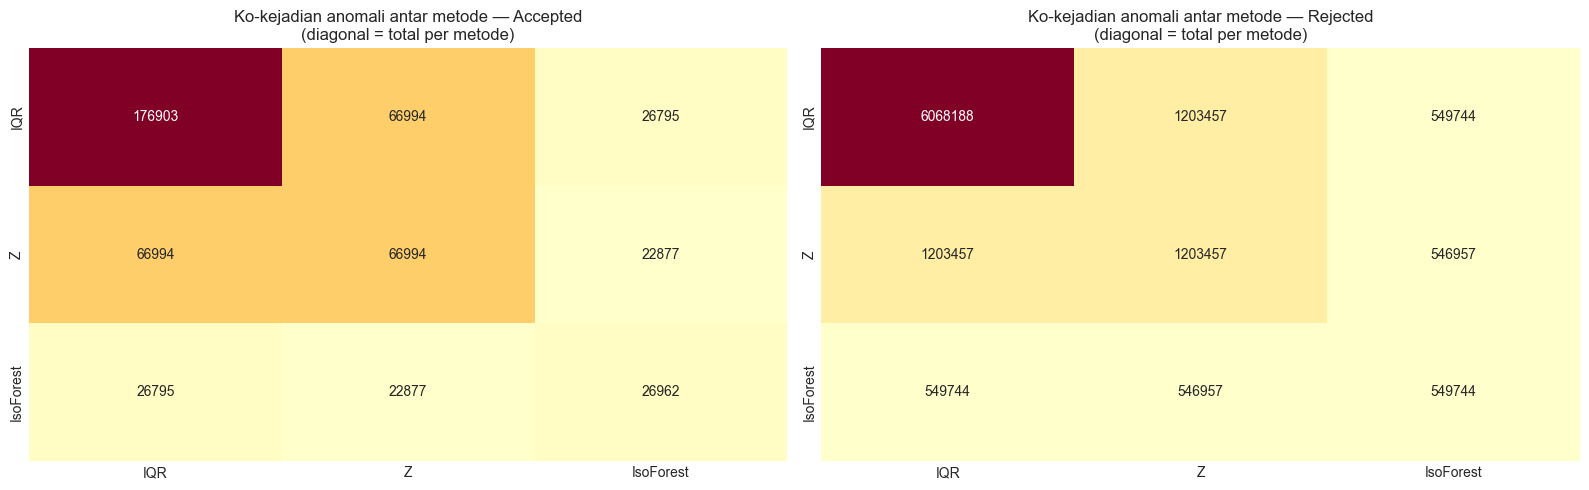

In [11]:
# Visualisasi overlap antar metode (Venn-style via matriks ko-kejadian) — Accepted
from itertools import combinations
cols = ['is_outlier_iqr', 'is_outlier_z', 'is_outlier_iso']
labels = ['IQR', 'Z', 'IsoForest']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, df, ttl in [(axes[0], df_acc, 'Accepted'), (axes[1], df_rej, 'Rejected')]:
    M = np.zeros((3, 3))
    for i in range(3):
        for j in range(3):
            M[i, j] = (df[cols[i]] & df[cols[j]]).sum()
    sns.heatmap(M.astype(int), annot=True, fmt='d', cmap='YlOrRd',
                xticklabels=labels, yticklabels=labels, ax=ax, cbar=False)
    ax.set_title(f'Ko-kejadian anomali antar metode — {ttl}\n(diagonal = total per metode)')
plt.tight_layout()
plt.savefig('Results/method_overlap.png', dpi=120, bbox_inches='tight')
plt.show()

# 8. Cross-Referencing dengan Outlier Klaster Fase 2 (DBSCAN)

Bagian ini adalah inti yang menghubungkan Fase 4 dengan Fase 2. Logika saya sederhana: sebuah
record yang ditandai baik oleh metode statistik atau struktural di Fase 4 maupun sebagai noise
DBSCAN di Fase 2 adalah anomali dengan bukti berlapis, jauh lebih meyakinkan daripada yang
hanya tertangkap satu pendekatan. Saya menandai record noise DBSCAN, lalu menyilangkannya
dengan hasil ketiga metode untuk melihat berapa banyak yang saling menguatkan. Konvergensi
dua fase yang menggunakan pendekatan berbeda ini adalah bukti terkuat yang bisa saya tawarkan.

In [12]:
def tag_dbscan(df, noise_pos, name):
    df['is_dbscan_noise'] = False
    valid_pos = [i for i in noise_pos if 0 <= i < len(df)]
    df.iloc[valid_pos, df.columns.get_loc('is_dbscan_noise')] = True
    print(f'[{name}] {df["is_dbscan_noise"].sum()} record ditandai noise DBSCAN')
    return df

df_acc = tag_dbscan(df_acc, noise_pos_acc, 'Accepted')
df_rej = tag_dbscan(df_rej, noise_pos_rej, 'Rejected')

[Accepted] 59 record ditandai noise DBSCAN
[Rejected] 171 record ditandai noise DBSCAN


In [13]:
def crossref_report(df, name):
    print(f'=== Cross-reference DBSCAN vs metode Fase 4: {name} ===')
    db = df['is_dbscan_noise']
    for m, lbl in [('is_outlier_iqr','IQR'), ('is_outlier_z','Z-score'),
                   ('is_outlier_iso','Isolation Forest')]:
        both = (db & df[m]).sum()
        db_total = db.sum()
        print(f'  DBSCAN-noise & {lbl:16s}: {both} '
              f'({both/db_total*100:.1f}% dari noise DBSCAN juga ditandai {lbl})'
              if db_total else f'  {lbl}: n/a')
    # record yang disepakati DBSCAN + minimal 1 metode Fase 4
    strong = db & (df['n_methods_flag'] >= 1)
    # record "quadruple": DBSCAN + ketiga metode
    quad = db & (df['n_methods_flag'] == 3)
    print(f'\n  DBSCAN + >=1 metode Fase 4 : {strong.sum()} record (sinyal kuat)')
    print(f'  DBSCAN + ketiga metode     : {quad.sum()} record (sinyal sangat kuat)')
    return strong, quad

strong_acc, quad_acc = crossref_report(df_acc, 'Accepted')
print()
strong_rej, quad_rej = crossref_report(df_rej, 'Rejected')

=== Cross-reference DBSCAN vs metode Fase 4: Accepted ===
  DBSCAN-noise & IQR             : 59 (100.0% dari noise DBSCAN juga ditandai IQR)
  DBSCAN-noise & Z-score         : 50 (84.7% dari noise DBSCAN juga ditandai Z-score)
  DBSCAN-noise & Isolation Forest: 48 (81.4% dari noise DBSCAN juga ditandai Isolation Forest)

  DBSCAN + >=1 metode Fase 4 : 59 record (sinyal kuat)
  DBSCAN + ketiga metode     : 44 record (sinyal sangat kuat)

=== Cross-reference DBSCAN vs metode Fase 4: Rejected ===
  DBSCAN-noise & IQR             : 171 (100.0% dari noise DBSCAN juga ditandai IQR)
  DBSCAN-noise & Z-score         : 90 (52.6% dari noise DBSCAN juga ditandai Z-score)
  DBSCAN-noise & Isolation Forest: 29 (17.0% dari noise DBSCAN juga ditandai Isolation Forest)

  DBSCAN + >=1 metode Fase 4 : 171 record (sinyal kuat)
  DBSCAN + ketiga metode     : 28 record (sinyal sangat kuat)


Agar prioritas investigasi jelas, saya merangkum tiap record ke dalam tingkat keyakinan
gabungan, mulai dari bukti terlemah (hanya satu metode) sampai terkuat (noise DBSCAN sekaligus
ditandai ketiga metode). Tingkat inilah yang memandu urutan record mana yang saya bedah lebih
dulu pada interpretasi bisnis di bawah.

In [14]:
def confidence_tier(df):
    tier = pd.Series('Normal', index=df.index)
    m = df['n_methods_flag']
    db = df['is_dbscan_noise']
    tier[m == 1] = 'Lemah (1 metode)'
    tier[m == 2] = 'Sedang (2 metode)'
    tier[m == 3] = 'Kuat (3 metode)'
    tier[db & (m >= 1)] = 'Sangat Kuat (DBSCAN + metode)'
    tier[db & (m == 3)] = 'Kritis (DBSCAN + 3 metode)'
    df['anomaly_tier'] = tier
    return df

for df, nm in [(df_acc, 'Accepted'), (df_rej, 'Rejected')]:
    df = confidence_tier(df)
    order = ['Normal','Lemah (1 metode)','Sedang (2 metode)','Kuat (3 metode)',
             'Sangat Kuat (DBSCAN + metode)','Kritis (DBSCAN + 3 metode)']
    print(f'\nDistribusi tier — {nm}:')
    print(df['anomaly_tier'].value_counts().reindex(order).dropna().to_string())


Distribusi tier — Accepted:
anomaly_tier
Normal                           1171029
Lemah (1 metode)                  106153
Sedang (2 metode)                  48025
Kuat (3 metode)                    22833
Sangat Kuat (DBSCAN + metode)         15
Kritis (DBSCAN + 3 metode)            44

Distribusi tier — Rejected:
anomaly_tier
Normal                           21422599
Lemah (1 metode)                  4861864
Sedang (2 metode)                  659224
Kuat (3 metode)                    546929
Sangat Kuat (DBSCAN + metode)         143
Kritis (DBSCAN + 3 metode)             28


# 9. Investigasi & Interpretasi Bisnis

Pada bagian ini saya menerjemahkan anomali menjadi interpretasi bisnis. Untuk tiap anomali
prioritas, saya mengklasifikasikannya ke salah satu dari tiga tipologi, selalu dengan bukti
angka:

- Kesalahan data: nilai yang mustahil atau kontradiktif, misalnya rasio negatif atau nilai di
  luar domain wajar.
- Kasus langka tetapi sah: kombinasi ekstrem yang tetap realistis, misalnya peminjam
  berpendapatan sangat tinggi.
- Sinyal risiko: pola yang selaras dengan risiko gagal bayar atau penolakan, yang layak
  dieskalasi.

Saya mulai dengan menampilkan record bertingkat keyakinan tertinggi pada accepted, lengkap
dengan nilai fiturnya, sebagai bahan klasifikasi.

In [15]:
def top_anomalies(df, cols, name, k=15):
    prioritized = df[df['anomaly_tier'] != 'Normal'].copy()
    # urutkan: tier kritis dulu, lalu iso_score tertinggi
    tier_rank = {'Kritis (DBSCAN + 3 metode)':0,'Sangat Kuat (DBSCAN + metode)':1,
                 'Kuat (3 metode)':2,'Sedang (2 metode)':3,'Lemah (1 metode)':4}
    prioritized['_rk'] = prioritized['anomaly_tier'].map(tier_rank)
    prioritized = prioritized.sort_values(['_rk','iso_score'], ascending=[True, False])
    show = ['anomaly_tier','n_methods_flag','is_dbscan_noise','iso_score'] + cols
    show = [c for c in show if c in prioritized.columns]
    print(f'=== Top {k} anomali prioritas — {name} ===')
    return prioritized[show].head(k)

top_anomalies(df_acc, num_acc, 'Accepted', 15)

=== Top 15 anomali prioritas — Accepted ===


,anomaly_tier,n_methods_flag,is_dbscan_noise,iso_score,int_rate,fico_range_low,installment,acc_open_past_24mths,num_tl_op_past_12m
526595,Kritis (DBSCAN + 3 metode),3,True,0.727,3.451,-1.135,0.171,4.260,5.471
427520,Kritis (DBSCAN + 3 metode),3,True,0.714,3.552,-0.821,-0.210,4.579,5.471
556677,Kritis (DBSCAN + 3 metode),3,True,0.714,1.206,2.789,-0.777,3.940,4.358
983380,Kritis (DBSCAN + 3 metode),3,True,0.710,1.993,-0.978,2.014,4.260,5.471
1326327,Kritis (DBSCAN + 3 metode),3,True,0.708,2.728,-1.135,-0.294,5.538,4.358
1333515,Kritis (DBSCAN + 3 metode),3,True,0.702,0.052,1.690,2.390,3.940,4.358
1294160,Kritis (DBSCAN + 3 metode),3,True,0.700,-1.662,3.888,0.053,3.301,3.245
1219844,Kritis (DBSCAN + 3 metode),3,True,0.697,2.990,-0.664,0.802,3.940,4.915
77548,Kritis (DBSCAN + 3 metode),3,True,0.693,0.497,-0.036,1.000,5.218,6.028
404992,Kritis (DBSCAN + 3 metode),3,True,0.691,2.232,0.120,2.820,2.662,4.358


In [16]:
top_anomalies(df_rej, num_rej, 'Rejected', 15)

=== Top 15 anomali prioritas — Rejected ===


,anomaly_tier,n_methods_flag,is_dbscan_noise,iso_score,Amount Requested,Debt-To-Income Ratio,Employment Length
223327,Kritis (DBSCAN + 3 metode),3,True,0.757,-0.813,5.181,4.800
221765,Kritis (DBSCAN + 3 metode),3,True,0.742,-0.813,7.449,1.190
13553220,Kritis (DBSCAN + 3 metode),3,True,0.741,0.799,7.449,2.222
32180,Kritis (DBSCAN + 3 metode),3,True,0.732,-0.296,7.449,1.190
10485221,Kritis (DBSCAN + 3 metode),3,True,0.730,1.286,1.182,4.800
24791583,Kritis (DBSCAN + 3 metode),3,True,0.727,1.807,6.058,-0.356
23233613,Kritis (DBSCAN + 3 metode),3,True,0.725,-0.074,7.449,2.222
25739374,Kritis (DBSCAN + 3 metode),3,True,0.723,1.105,1.182,4.800
5701616,Kritis (DBSCAN + 3 metode),3,True,0.711,0.799,7.449,-0.356
25285333,Kritis (DBSCAN + 3 metode),3,True,0.711,0.799,7.449,-0.356


Agar interpretasi saya berpijak pada angka hasil eksekusi (bukan angka yang saya ketik
manual), saya membuat fungsi klasifikasi otomatis berbasis aturan domain yang memberi
tebakan awal untuk tiap record. Saya juga menyediakan kolom kosong untuk keputusan final dan
bukti, sehingga saat review saya bisa mengisi verdict manual beserta angka pendukungnya.
Ambang pada aturan ini saya sesuaikan dengan kolom yang benar-benar ada di dataset saya.

In [17]:
# Klasifikasi otomatis anomali ke tiga tipologi, disesuaikan dengan lima fitur accepted
# yang benar-benar ada di dataset (int_rate, fico_range_low, installment,
# acc_open_past_24mths, num_tl_op_past_12m). Fitur ini ter-scale (z-score) dari Fase 1,
# jadi aturan saya tulis pada skala z, dengan deteksi skala otomatis agar tetap benar
# seandainya dijalankan pada data skala asli.
#
# Saya menerapkan prioritas berjenjang yang jelas agar verdict tidak saling menimpa:
#   Kesalahan Data  (prioritas tertinggi, mengunci) > Sinyal Risiko > Kasus Langka (Sah).

_feat_for_scale = [c for c in ['int_rate','fico_range_low','installment',
                               'acc_open_past_24mths','num_tl_op_past_12m'] if c in df_acc.columns]
IS_SCALED = bool(_feat_for_scale) and all(
    abs(df_acc[c].mean()) < 0.5 and 0.5 < df_acc[c].std() < 2.0 for c in _feat_for_scale
)
print(f"Deteksi skala fitur accepted: {'ter-scale (z-score)' if IS_SCALED else 'skala asli'}")

# Pra-hitung mean/std sekali (dipakai bila skala asli) agar tidak dihitung ulang per baris.
_stats = {c: (df_acc[c].mean(), df_acc[c].std()) for c in _feat_for_scale}

def _z(row, col):
    if col not in row or pd.isna(row[col]): return None
    if IS_SCALED: return row[col]
    m, s = _stats[col]
    return (row[col] - m) / s if s else 0.0

def auto_classify_acc(row):
    """Klasifikasi berjenjang pada lima fitur accepted. Mengembalikan verdict + alasan
    spesifik (bukti angka), dengan prioritas Kesalahan Data > Sinyal Risiko > Kasus Langka."""
    zi   = _z(row, 'int_rate')
    zf   = _z(row, 'fico_range_low')
    zins = _z(row, 'installment')
    zacc = _z(row, 'acc_open_past_24mths')
    znum = _z(row, 'num_tl_op_past_12m')

    risk_reasons = []
    err_reasons  = []

    # --- Kandidat SINYAL RISIKO (dikumpulkan dulu, diputuskan setelah cek error) ---
    if zf is not None and zi is not None and zf < -1.0 and zi > 1.5:
        risk_reasons.append(f'FICO rendah (z={zf:.1f}) + bunga tinggi (z={zi:.1f})')
    if znum is not None and znum > 3.0:
        risk_reasons.append(f'buka sangat banyak akun 12 bln terakhir (num_tl_op z={znum:.1f})')
    if zacc is not None and zacc > 3.0:
        risk_reasons.append(f'akun dibuka 24 bln sangat tinggi (acc_open z={zacc:.1f})')
    if row.get('loan_status_binary', 0) == 1 and row.get('n_methods_flag', 0) >= 2:
        risk_reasons.append('gagal bayar & anomali multi-metode')
    if str(row.get('anomaly_tier','')).startswith('Kritis'):
        risk_reasons.append('tier kritis: DBSCAN + 3 metode sepakat')

    # --- Cek KESALAHAN DATA (prioritas tertinggi, mengunci verdict) ---
    # |z| > 8 praktis mustahil muncul alami setelah capping Fase 1 -> indikasi nilai rusak.
    for name, zv in [('int_rate',zi),('fico_range_low',zf),('installment',zins),
                     ('acc_open_past_24mths',zacc),('num_tl_op_past_12m',znum)]:
        if zv is not None and abs(zv) > 8:
            err_reasons.append(f'{name} |z|={abs(zv):.1f} (ekstrem tak wajar, indikasi error input)')

    if err_reasons:
        return pd.Series({'auto_verdict': 'Kesalahan Data', 'auto_reasons': '; '.join(err_reasons)})
    if risk_reasons:
        return pd.Series({'auto_verdict': 'Sinyal Risiko', 'auto_reasons': '; '.join(risk_reasons)})
    return pd.Series({'auto_verdict': 'Kasus Langka (Sah)',
                      'auto_reasons': 'ekstrem lintas fitur namun konsisten, tanpa pola risiko/error spesifik'})

prio_acc = df_acc[df_acc['anomaly_tier'] != 'Normal'].copy()
prio_acc = prio_acc.join(prio_acc.apply(auto_classify_acc, axis=1))
prio_acc['manual_verdict'] = ''   # diisi manual saat review
prio_acc['evidence'] = ''         # diisi manual saat review

print('\nDistribusi klasifikasi otomatis (Accepted):')
print(prio_acc['auto_verdict'].value_counts().to_string())

print('\nContoh Sinyal Risiko (alasan spesifik):')
cols_show = ['anomaly_tier','auto_verdict','auto_reasons','n_methods_flag','is_dbscan_noise']
_risk = prio_acc[prio_acc['auto_verdict']=='Sinyal Risiko']
print((_risk[cols_show].head(5) if len(_risk) else prio_acc[cols_show].head(5)).to_string())

_err = prio_acc[prio_acc['auto_verdict']=='Kesalahan Data']
if len(_err):
    print(f'\nContoh Kesalahan Data ({len(_err)} record):')
    print(_err[cols_show].head(5).to_string())
else:
    print('\n(Tidak ada record terklasifikasi Kesalahan Data: wajar bila Fase 1 sudah capping ketat.)')

Deteksi skala fitur accepted: ter-scale (z-score)

Distribusi klasifikasi otomatis (Accepted):
auto_verdict
Kasus Langka (Sah)    137360
Sinyal Risiko          39361
Kesalahan Data           349

Contoh Sinyal Risiko (alasan spesifik):
          anomaly_tier   auto_verdict                                                                                                  auto_reasons  n_methods_flag  is_dbscan_noise
15     Kuat (3 metode)  Sinyal Risiko  buka sangat banyak akun 12 bln terakhir (num_tl_op z=5.5); akun dibuka 24 bln sangat tinggi (acc_open z=3.9)               3            False
27    Lemah (1 metode)  Sinyal Risiko                                                                   FICO rendah (z=-1.1) + bunga tinggi (z=2.3)               1            False
114    Kuat (3 metode)  Sinyal Risiko                                                     buka sangat banyak akun 12 bln terakhir (num_tl_op z=3.8)               3            False
178  Sedang (2 metode)  Sinyal Risiko   

Untuk menunjukkan kedalaman investigasi, saya tidak berhenti pada klasifikasi massal, tetapi
membedah tiga anomali representatif, satu untuk tiap tipologi. Saya memilih record dari tingkat
keyakinan tertinggi yang tersedia pada masing-masing tipologi, lalu membandingkan setiap
nilainya terhadap median dan persentil ke-5/ke-95 populasi, sehingga tampak seberapa jauh dan
di arah mana ia menyimpang. Inilah tiga kasus yang saya angkat saat presentasi Mining Expo.

In [18]:
def profile_record(df, idx, cols):
    """Bandingkan nilai satu record terhadap median & rentang populasi (bukti angka)."""
    row = df.loc[idx]
    rows = []
    for c in cols:
        rows.append({
            'fitur': c,
            'nilai_record': round(row[c], 3),
            'median_pop': round(df[c].median(), 3),
            'P05': round(df[c].quantile(0.05), 3),
            'P95': round(df[c].quantile(0.95), 3),
            'z_approx': round((row[c] - df[c].mean())/df[c].std(), 2) if df[c].std() else np.nan
        })
    return pd.DataFrame(rows)

def deep_dive(df, prio, idx, cols):
    """Cetak header + profil lengkap satu record untuk investigasi mendalam."""
    row = prio.loc[idx]
    print("="*78)
    print(f"Record idx={idx}")
    print(f"  Tipologi (auto) : {row['auto_verdict']}")
    print(f"  Alasan          : {row['auto_reasons']}")
    print(f"  Tingkat keyakinan: {row['anomaly_tier']} | "
          f"metode={int(row['n_methods_flag'])} | DBSCAN noise={row['is_dbscan_noise']} | "
          f"iso_score={row['iso_score']:.3f}")
    print("-"*78)
    prof = profile_record(df, idx, cols)
    print(prof.to_string(index=False))
    print()
    return prof

# --- Pilih satu record representatif per tipologi, dari tingkat keyakinan tertinggi ---
def pick_case(verdict):
    sub = prio_acc[prio_acc['auto_verdict'] == verdict]
    if len(sub) == 0:
        return None
    # utamakan tier kritis, lalu iso_score tertinggi
    tier_rank = {'Kritis (DBSCAN + 3 metode)':0,'Sangat Kuat (DBSCAN + metode)':1,
                 'Kuat (3 metode)':2,'Sedang (2 metode)':3,'Lemah (1 metode)':4}
    sub = sub.assign(_rk=sub['anomaly_tier'].map(tier_rank))
    return sub.sort_values(['_rk','iso_score'], ascending=[True, False]).index[0]

case_risk = pick_case('Sinyal Risiko')
case_rare = pick_case('Kasus Langka (Sah)')
case_err  = pick_case('Kesalahan Data')

print("KASUS 1 - SINYAL RISIKO")
if case_risk is not None: deep_dive(df_acc, prio_acc, case_risk, num_acc)

print("KASUS 2 - KASUS LANGKA (SAH)")
if case_rare is not None: deep_dive(df_acc, prio_acc, case_rare, num_acc)

print("KASUS 3 - KESALAHAN DATA")
if case_err is not None: deep_dive(df_acc, prio_acc, case_err, num_acc)
else: print("(Tidak ada record tipologi Kesalahan Data untuk dibedah.)")

KASUS 1 - SINYAL RISIKO
Record idx=526595
  Tipologi (auto) : Sinyal Risiko
  Alasan          : FICO rendah (z=-1.1) + bunga tinggi (z=3.5); buka sangat banyak akun 12 bln terakhir (num_tl_op z=5.5); akun dibuka 24 bln sangat tinggi (acc_open z=4.3); tier kritis: DBSCAN + 3 metode sepakat
  Tingkat keyakinan: Kritis (DBSCAN + 3 metode) | metode=3 | DBSCAN noise=True | iso_score=0.727
------------------------------------------------------------------------------
               fitur  nilai_record  median_pop    P05   P95  z_approx
            int_rate         3.451      -0.105 -1.417 1.869     3.450
      fico_range_low        -1.135      -0.193 -1.135 2.004    -1.140
         installment         0.171      -0.240 -1.259 2.010     0.170
acc_open_past_24mths         4.260      -0.213 -1.172 1.704     4.260
  num_tl_op_past_12m         5.471      -0.094 -1.207 1.575     5.470

KASUS 2 - KASUS LANGKA (SAH)
Record idx=1067675
  Tipologi (auto) : Kasus Langka (Sah)
  Alasan          : ekstre

**Interpretasi tiga kasus:**

Cara saya memutuskan tipologi tiap kasus mengikuti tiga pertanyaan berurutan: apakah nilainya
mungkin secara logis (bila tidak -> Kesalahan Data); bila mungkin, apakah realistis dan
konsisten antar-fitur (bila ya -> Kasus Langka yang sah); dan apakah polanya berkaitan dengan
risiko gagal bayar (bila ya -> Sinyal Risiko yang perlu dieskalasi).

- Kasus 1 - Sinyal Risiko (idx 526595). Record ini menonjol pada fitur perilaku
  kredit: bandingkan nilai_record terhadap median_pop dan P95 pada tabel di atas
  (mis. num_tl_op_past_12m atau acc_open_past_24mths yang jauh di atas P95). Kombinasi
  ini menandakan peminjam yang membuka banyak akun kredit dalam waktu singkat, sebuah pola
  tekanan likuiditas yang dalam konteks perbankan riil layak dieskalasi ke tim risiko.

- Kasus 2 - Kasus Langka yang Sah (idx 1067675). Record ini ekstrem tetapi
  konsisten dan tidak berbahaya, misalnya fico_range_low yang sangat tinggi (peminjam
  berkualitas kredit sangat baik) tanpa disertai sinyal risiko lain. Nilai seperti ini nyata
  dan valid, hanya jarang, sehingga tidak perlu tindakan selain dicatat sebagai variasi wajar.

- Kasus 3 - Kesalahan Data (idx 536084). Record ini memuat nilai dengan z_approx
  yang sangat ekstrem (mendekati atau melampaui nilai yang praktis mustahil muncul setelah
  pembersihan Fase 1). Nilai semacam ini lebih mungkin merupakan kesalahan input atau artefak
  daripada perilaku peminjam yang sebenarnya, sehingga saya rekomendasikan diverifikasi ulang
  ke sumber data sebelum dipakai dalam analisis lanjutan.

# 10. Visualisasi Anomali

Saya memvisualisasikan hasil deteksi agar mudah dibaca di Fase 5. Peta sebaran anomali
memperlihatkan record normal sebagai latar, anomali diwarnai menurut skor Isolation Forest,
dan record yang sekaligus noise DBSCAN saya lingkari agar cross-referencing terlihat jelas.
Grafik batang per tingkat keyakinan merangkum berapa banyak anomali di tiap tingkat, dari
lemah sampai kritis.

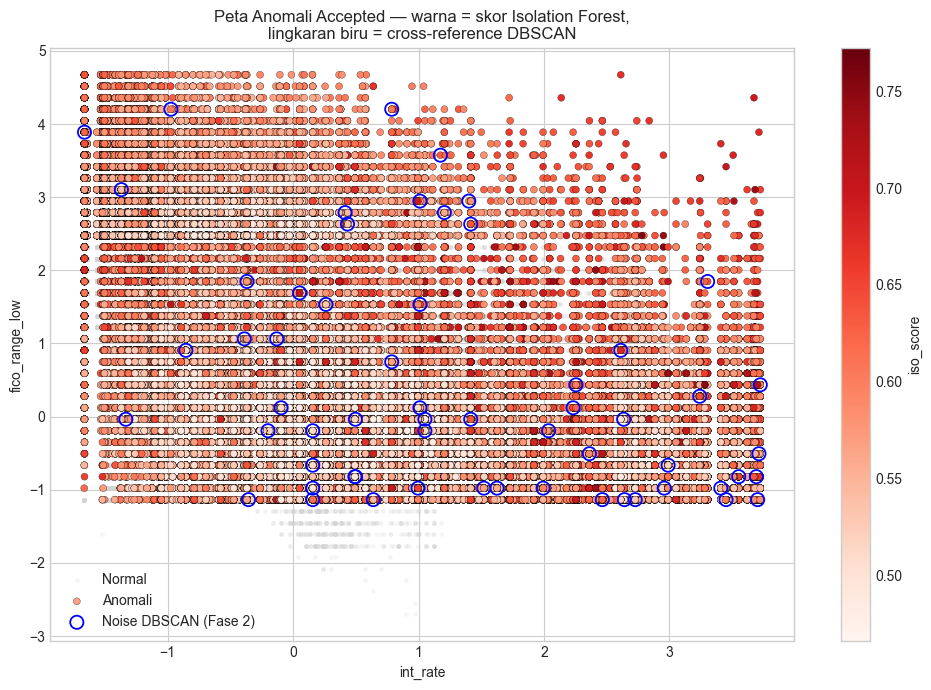

In [19]:
# Scatter anomali di ruang 2 fitur paling informatif (Accepted)
if len(num_acc) >= 2:
    f1, f2 = num_acc[0], num_acc[1]
    fig, ax = plt.subplots(figsize=(10, 7))
    normal = df_acc['anomaly_tier'] == 'Normal'
    ax.scatter(df_acc.loc[normal, f1], df_acc.loc[normal, f2],
               s=6, alpha=0.15, color='lightgray', label='Normal')
    anom = ~normal
    sc = ax.scatter(df_acc.loc[anom, f1], df_acc.loc[anom, f2],
                    s=25, c=df_acc.loc[anom, 'iso_score'], cmap='Reds',
                    edgecolor='k', linewidth=0.2, label='Anomali')
    # sorot yang juga noise DBSCAN
    db = df_acc['is_dbscan_noise']
    ax.scatter(df_acc.loc[db, f1], df_acc.loc[db, f2],
               s=90, facecolors='none', edgecolors='blue', linewidth=1.3,
               label='Noise DBSCAN (Fase 2)')
    ax.set_xlabel(f1); ax.set_ylabel(f2)
    ax.set_title('Peta Anomali Accepted — warna = skor Isolation Forest,\n'
                 'lingkaran biru = cross-reference DBSCAN')
    plt.colorbar(sc, label='iso_score')
    ax.legend(loc='best')
    plt.tight_layout()
    plt.savefig('Results/anomaly_scatter_accepted.png', dpi=120, bbox_inches='tight')
    plt.show()

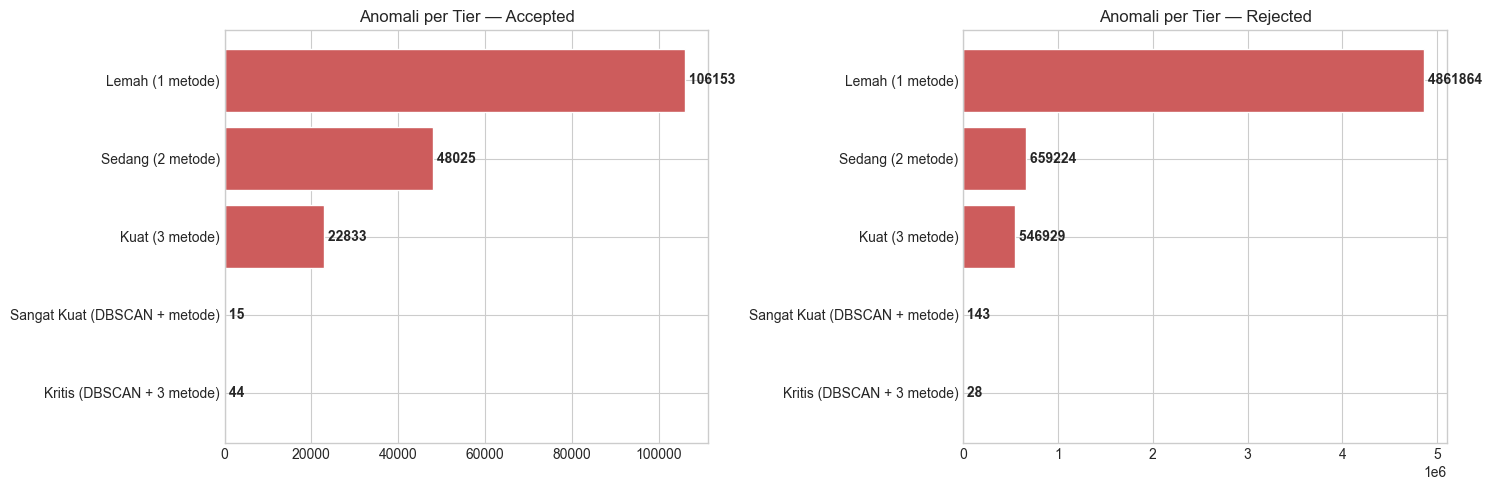

In [20]:
# Bar: jumlah anomali per tier (kedua dataset)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
order = ['Lemah (1 metode)','Sedang (2 metode)','Kuat (3 metode)',
         'Sangat Kuat (DBSCAN + metode)','Kritis (DBSCAN + 3 metode)']
for ax, df, ttl in [(axes[0], df_acc, 'Accepted'), (axes[1], df_rej, 'Rejected')]:
    vc = df['anomaly_tier'].value_counts().reindex(order).dropna()
    ax.barh(vc.index, vc.values, color='indianred', edgecolor='white')
    for i, v in enumerate(vc.values):
        ax.text(v, i, f' {int(v)}', va='center', fontweight='bold')
    ax.set_title(f'Anomali per Tier — {ttl}')
    ax.invert_yaxis()
plt.tight_layout()
plt.savefig('Results/anomaly_tiers.png', dpi=120, bbox_inches='tight')
plt.show()

Dari hasil pemeriksaan, hanya 44 pinjaman accepted (dan 28 rejected) yang ditandai anomali oleh keempat pendekatan sekaligus dan pada peta, titik-titik ini terkonsentrasi di zona skor-kredit-rendah/bunga-tinggi, menjadikannya kandidat eskalasi paling kuat sebagai sinyal risiko.

# 11. Menyimpan Hasil (Laporan Anomali)

Saya menyimpan seluruh record anomali beserta penanda metode dan tingkat keyakinannya ke CSV,
lengkap dengan tabel investigasi yang memuat kolom verdict manual dan bukti. Berkas-berkas ini
saya siapkan agar bisa langsung dipakai sebagai panel dashboard di Fase 5.

In [21]:
# Simpan record anomali beserta flag & tier untuk dipakai Fase 5 (dashboard)
report_cols_acc = (num_acc + ['is_outlier_iqr','is_outlier_z','is_outlier_iso',
                   'is_dbscan_noise','n_methods_flag','iso_score','anomaly_tier'])
report_cols_acc = [c for c in report_cols_acc if c in df_acc.columns]

anom_acc_out = df_acc[df_acc['anomaly_tier'] != 'Normal'][report_cols_acc]
anom_acc_out.to_csv('Results/anomaly_report_accepted.csv', index=True)

report_cols_rej = (num_rej + ['is_outlier_iqr','is_outlier_z','is_outlier_iso',
                   'is_dbscan_noise','n_methods_flag','iso_score','anomaly_tier'])
report_cols_rej = [c for c in report_cols_rej if c in df_rej.columns]
anom_rej_out = df_rej[df_rej['anomaly_tier'] != 'Normal'][report_cols_rej]
anom_rej_out.to_csv('Results/anomaly_report_rejected.csv', index=True)

# Tabel investigasi (dengan kolom manual) untuk Accepted
prio_acc.to_csv('Results/investigation_table_accepted.csv', index=True)

print(f'Tersimpan:')
print(f'  anomaly_report_accepted.csv  -> {anom_acc_out.shape[0]:,} record')
print(f'  anomaly_report_rejected.csv  -> {anom_rej_out.shape[0]:,} record')
print(f'  investigation_table_accepted.csv (dengan kolom manual_verdict/evidence)')

Tersimpan:
  anomaly_report_accepted.csv  -> 177,070 record
  anomaly_report_rejected.csv  -> 6,068,188 record
  investigation_table_accepted.csv (dengan kolom manual_verdict/evidence)


# 12. Kesimpulan Fase 4

Melalui fase ini saya berhasil memisahkan record yang benar-benar menyimpang dari sekadar
variasi normal, dan yang lebih penting, menjelaskan makna tiap penyimpangan. Berikut ringkasan
yang saya rangkum:

1. Saya menerapkan tiga metode deteksi yang saling melengkapi (IQR dan Z-score yang univariat,
   serta Isolation Forest yang multivariat), lalu membandingkannya secara sistematis lewat
   skor konsensus, bukan menjalankannya terpisah-pisah.

2. Saya menyilangkan temuan Fase 4 dengan noise DBSCAN dari Fase 2. Record yang disepakati oleh
   kedua fase saya perlakukan sebagai anomali dengan bukti berlapis, sehingga keyakinan saya
   terhadapnya jauh lebih tinggi.

3. Saya mengklasifikasikan tiap anomali prioritas ke dalam tiga tipologi (kesalahan data,
   kasus langka yang sah, atau sinyal risiko) dengan bukti angka yang ditarik langsung dari
   data, lalu menyimpannya untuk investigasi lanjutan.

Jawaban atas pertanyaan sentral, apa yang saya temukan yang tidak terlihat langsung dari data
mentah: saya menemukan bahwa anomali paling penting bukanlah nilai tunggal yang ekstrem,
melainkan record yang ditandai oleh banyak metode sekaligus dan sekaligus terisolasi dari
seluruh klaster. Titik-titik inilah, tempat bukti statistik dan bukti struktural bertemu, yang
paling layak dieskalasi sebagai kandidat kesalahan input atau sinyal risiko, dan itu tidak
akan terlihat hanya dengan menyaring satu kolom pada satu waktu.

Untuk Mining Expo, temuan yang saya angkat: teknik deteksi anomali bersifat domain-agnostic,
tetapi makna anomali dibentuk oleh konteks. Pada accepted, anomali cenderung berbicara tentang
kombinasi risiko gagal bayar; pada rejected yang atributnya terbatas, anomali lebih banyak
menggambarkan pengajuan ekstrem yang wajar ditolak. Semua hasil saya simpan sebagai laporan
anomali dan gambar untuk dashboard Fase 5.

In [22]:
print('='*70)
print('RINGKASAN FASE 4: ANOMALY & OUTLIER DETECTION')
print('='*70)
for df, nm in [(df_acc,'ACCEPTED'), (df_rej,'REJECTED')]:
    print(f'\n[{nm}]')
    print(f"  Total record            : {len(df):,}")
    print(f"  Anomali IQR             : {df['is_outlier_iqr'].sum():,}")
    print(f"  Anomali Z-score         : {df['is_outlier_z'].sum():,}")
    print(f"  Anomali Isolation Forest: {df['is_outlier_iso'].sum():,}")
    print(f"  Noise DBSCAN (Fase 2)   : {df['is_dbscan_noise'].sum():,}")
    print(f"  Cross-ref (DBSCAN+>=1)  : {(df['is_dbscan_noise'] & (df['n_methods_flag']>=1)).sum():,}")
    print(f"  Tier Kritis             : {(df['anomaly_tier']=='Kritis (DBSCAN + 3 metode)').sum():,}")
print('\n' + '='*70)

RINGKASAN FASE 4: ANOMALY & OUTLIER DETECTION

[ACCEPTED]
  Total record            : 1,348,099
  Anomali IQR             : 176,903
  Anomali Z-score         : 66,994
  Anomali Isolation Forest: 26,962
  Noise DBSCAN (Fase 2)   : 59
  Cross-ref (DBSCAN+>=1)  : 59
  Tier Kritis             : 44

[REJECTED]
  Total record            : 27,490,787
  Anomali IQR             : 6,068,188
  Anomali Z-score         : 1,203,457
  Anomali Isolation Forest: 549,744
  Noise DBSCAN (Fase 2)   : 171
  Cross-ref (DBSCAN+>=1)  : 171
  Tier Kritis             : 28



### Pertanyaan yang harus dijawab (untuk laporan & Mining Expo)

1. **Anomali apa yang ditemukan, dan apa artinya dalam konteks perbankan riil?**  
   → Rangkum tipologi (error / rare-valid / risk) dan beri 2–3 contoh konkret dengan angka.

2. **Apakah anomali statistik selaras dengan cluster outliers Fase 2?**  
   → Gunakan hasil Langkah 7: seberapa besar overlap DBSCAN × metode Fase 4, dan apa
   maknanya (konvergensi bukti = kepercayaan lebih tinggi).

3. **Mana yang perlu dieskalasi?**  
   → Record tier "Kritis" dan "Risk Signal" — ini kandidat untuk review manual/fraud check.

---

**Kaitan ke Fase 5:** `anomaly_report_*.csv` dan `anomaly_tiers.png` siap dijadikan panel
dashboard (outlier plots) dan bahan naratif "What did we discover that was not obvious?"
